
IDEAL VS IMPERFECT HADAMARD GATE

IDEAL HADAMARD CIRCUIT
----------------------------------------------------------------------
   ┌───┐
q: ┤ H ├
   └───┘

IDEAL MEASUREMENT RESULTS
----------------------------------------------------------------------
Shots                 : 1000
0 count               : 503
1 count               : 497
P(0)                  : 0.5000
P(1)                  : 0.5000

IMPERFECT HADAMARD CIRCUIT
----------------------------------------------------------------------
   ┌──────────┐┌───┐
q: ┤ Ry(π/18) ├┤ H ├
   └──────────┘└───┘

IMPERFECT MEASUREMENT RESULTS
----------------------------------------------------------------------
Shots                 : 1000
0 count               : 586
1 count               : 414
P(0)                  : 0.5868
P(1)                  : 0.4132

COMPARISON
----------------------------------------------------------------------
Difference in P(0)    : 0.0868
Difference in P(1)    : 0.0868
Result                : Deviation observed


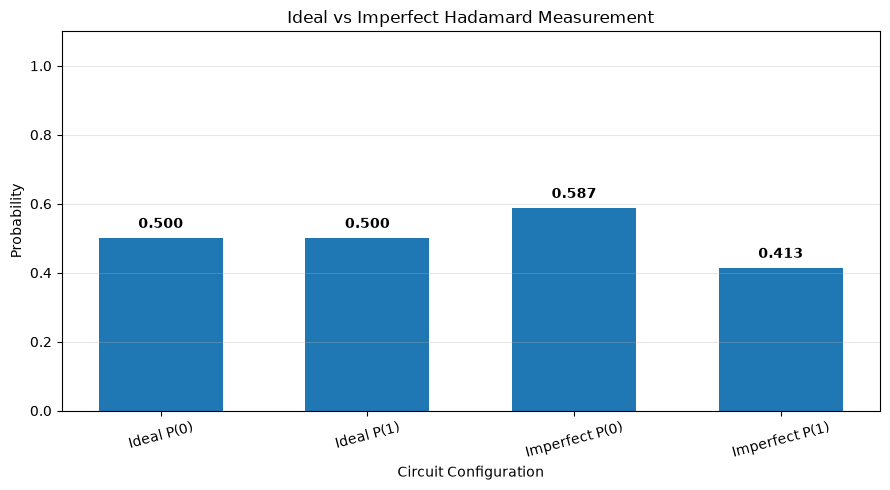

In [1]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
import numpy as np
import matplotlib.pyplot as plt

SHOTS = 1000

# ---------------------------------------------------------
# IDEAL HADAMARD CIRCUIT
# ---------------------------------------------------------

ideal = QuantumCircuit(1)

ideal.h(0)

# ---------------------------------------------------------
# IMPERFECT HADAMARD CIRCUIT
# ---------------------------------------------------------

imperfect = QuantumCircuit(1)

# Small rotation error is introduced before H
imperfect.ry(np.pi / 18, 0)
imperfect.h(0)

# ---------------------------------------------------------
# FUNCTION TO CALCULATE PROBABILITIES
# ---------------------------------------------------------

def get_probabilities(circuit):

    state = Statevector.from_instruction(circuit)

    probabilities = state.probabilities()

    p0 = probabilities[0]
    p1 = probabilities[1]

    return p0, p1

# ---------------------------------------------------------
# IDEAL RESULTS
# ---------------------------------------------------------

ideal_p0, ideal_p1 = get_probabilities(ideal)

# ---------------------------------------------------------
# IMPERFECT RESULTS
# ---------------------------------------------------------

imperfect_p0, imperfect_p1 = get_probabilities(imperfect)

# ---------------------------------------------------------
# SIMULATED MEASUREMENTS
# ---------------------------------------------------------

rng = np.random.default_rng(42)

ideal_samples = rng.choice(
    [0, 1],
    size=SHOTS,
    p=[ideal_p0, ideal_p1]
)

imperfect_samples = rng.choice(
    [0, 1],
    size=SHOTS,
    p=[imperfect_p0, imperfect_p1]
)

ideal_count0 = int(np.sum(ideal_samples == 0))
ideal_count1 = int(np.sum(ideal_samples == 1))

imperfect_count0 = int(np.sum(imperfect_samples == 0))
imperfect_count1 = int(np.sum(imperfect_samples == 1))

# ---------------------------------------------------------
# OUTPUT
# ---------------------------------------------------------

print("\nIDEAL VS IMPERFECT HADAMARD GATE")
print("=" * 70)

# ---------------------------------------------------------
# IDEAL CIRCUIT OUTPUT
# ---------------------------------------------------------

print("\nIDEAL HADAMARD CIRCUIT")
print("-" * 70)
print(ideal.draw())

print("\nIDEAL MEASUREMENT RESULTS")
print("-" * 70)

print(f"Shots                 : {SHOTS}")
print(f"0 count               : {ideal_count0}")
print(f"1 count               : {ideal_count1}")
print(f"P(0)                  : {ideal_p0:.4f}")
print(f"P(1)                  : {ideal_p1:.4f}")

# ---------------------------------------------------------
# IMPERFECT CIRCUIT OUTPUT
# ---------------------------------------------------------

print("\nIMPERFECT HADAMARD CIRCUIT")
print("-" * 70)
print(imperfect.draw())

print("\nIMPERFECT MEASUREMENT RESULTS")
print("-" * 70)

print(f"Shots                 : {SHOTS}")
print(f"0 count               : {imperfect_count0}")
print(f"1 count               : {imperfect_count1}")
print(f"P(0)                  : {imperfect_p0:.4f}")
print(f"P(1)                  : {imperfect_p1:.4f}")

# ---------------------------------------------------------
# COMPARISON
# ---------------------------------------------------------

print("\nCOMPARISON")
print("-" * 70)

difference_p0 = abs(ideal_p0 - imperfect_p0)
difference_p1 = abs(ideal_p1 - imperfect_p1)

print(f"Difference in P(0)    : {difference_p0:.4f}")
print(f"Difference in P(1)    : {difference_p1:.4f}")

if difference_p0 < 0.01 and difference_p1 < 0.01:
    print("Result                : Nearly ideal")
else:
    print("Result                : Deviation observed")

# ---------------------------------------------------------
# VISUALISATION
# ---------------------------------------------------------

labels = [
    "Ideal P(0)",
    "Ideal P(1)",
    "Imperfect P(0)",
    "Imperfect P(1)"
]

values = [
    ideal_p0,
    ideal_p1,
    imperfect_p0,
    imperfect_p1
]

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    labels,
    values,
    width=0.6
)

ax.set_title(
    "Ideal vs Imperfect Hadamard Measurement"
)

ax.set_xlabel(
    "Circuit Configuration"
)

ax.set_ylabel(
    "Probability"
)

ax.set_ylim(0, 1.1)

for bar, value in zip(bars, values):

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.03,
        f"{value:.3f}",
        ha="center",
        fontweight="bold"
    )

ax.grid(
    axis="y",
    alpha=0.3
)

plt.xticks(
    rotation=15
)

plt.tight_layout()
plt.show()